# Use SurvivalEVAL for scikit-survival model

In this notebook we introduce the use of `ScikitSurvivalEvaluator` in the package to evaluate the performance for a scikit-survival model.
The first half of this notebook follows the procedure described in the Scikit-Survival [example](https://github.com/havakv/pycox/blob/master/examples/01_introduction.ipynb).


In the following, we will:
1. Load the German Breast Cancer Study Group 2 dataset;
2. Train the `CoxPH` model using 70% of the data;
3. Perform evaluation on the 30% testing set.

In [1]:
%pip install scikit-survival

Note: you may need to restart the kernel to use updated packages.


## Import Dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sksurv.datasets import load_gbsg2
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.preprocessing import OneHotEncoder, encode_categorical
from sksurv.metrics import check_y_survival

from SurvivalEVAL import ScikitSurvivalEvaluator

In [3]:
%matplotlib inline

## Load and prepare data.

In [4]:
X, y = load_gbsg2()
Xt = encode_categorical(X)
X = X.copy()
X["tgrade"] = X["tgrade"].map(len).astype(int)
Xt = OneHotEncoder().fit_transform(X)

In [5]:
n = len(Xt)

tr_size = int(n*0.70)

Xt_train, Xt_test = Xt.iloc[:tr_size, :], Xt.iloc[tr_size:, :]
y_train, y_test = y[:tr_size], y[tr_size:]
train_event_indicators, train_event_times = check_y_survival(y_train)
test_event_indicators, test_event_times = check_y_survival(y_test)


## Build the model and train it.

In [6]:
est = CoxPHSurvivalAnalysis(ties="efron").fit(Xt_train, y_train)

## Predict individual survival functions
Get probability of remaining event free from 1 year to 5 years (=1825 days).

In [7]:
survs = est.predict_survival_function(Xt_test)

## Build the evaluator.
Some arguments includes:
1. Training set information (`durations_train` and `events_train`) is optional if you don't need Brier score, integrated Brier score, and L1-margin loss.
2. `predicted_time_method` argument indicates whether using median or mean survival time as the predicted time.

In [8]:
eval = ScikitSurvivalEvaluator(survs, test_event_times, test_event_indicators, train_event_times, train_event_indicators, predict_time_method="Median")

## Make some example plots

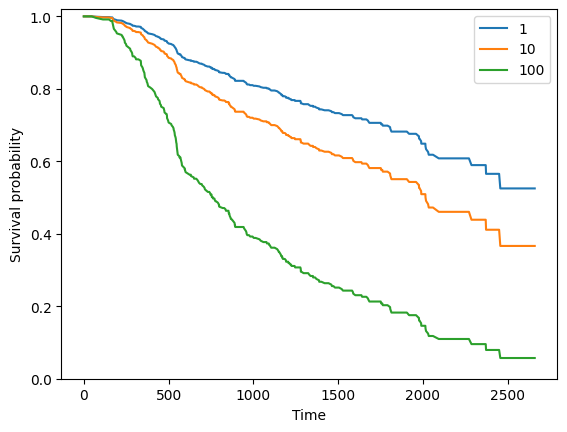

In [9]:
fig, ax = eval.plot_survival_curves([1, 10, 100])
plt.show()

## Calculate the concordance index.
`ties` argument indicates the way ties should be handled.
`ties="None"` will throw out all ties in true survival time and all ties in predict survival times (risk scores).
`ties="Time"` includes ties in true survival time but removes ties in predict survival times (risk scores).
`ties="Risk"` includes ties in predict survival times (risk scores) but not in true survival time.
`ties="All"` includes all ties.

In [10]:

cindex, concordant_pairs, total_pairs = eval.concordance(ties="None")
print("Concordance index is {}, meaning that the model can correctly order {} pairs among {} comparable pairs "
      "in the testing set.".format(cindex, concordant_pairs, total_pairs))

Concordance index is 0.6612887062831947, meaning that the model can correctly order 6599.0 pairs among 9979.0 comparable pairs in the testing set.


## Calculate the Brier score
Target time is at time 175. You could use any time as preferred.

In [11]:
bs = eval.brier_score(target_time=175)
print("Brier score at time 175 is {}.".format(bs))

Brier score at time 175 is 0.009235037097327979.


## Calculate the integrated Brier score (IBS)
- You can specify the number of points `num_points` to integral. If it is not specify, the default setting will use the censored time points obtained from testing set.
- You can also set the `IPCW_weighted` as True or False to calculate the IPCW-weighted IBS or non-weighted IBS. The default setting is True.

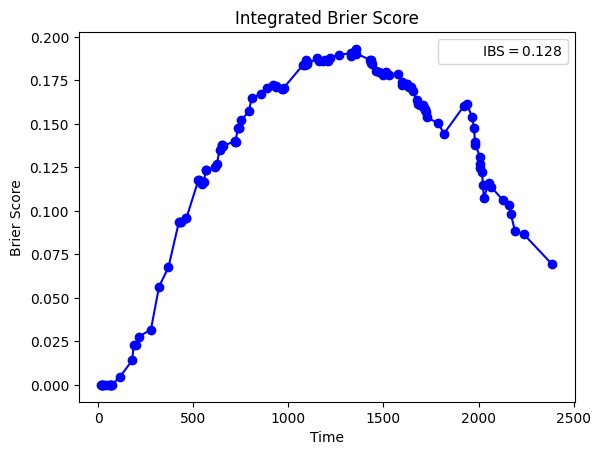

Integrated Brier score is 0.12826211601248272.


In [12]:
ibs, (fig, ax) = eval.integrated_brier_score(num_points=None, IPCW_weighted=True, draw_figure=True)
print("Integrated Brier score is {}.".format(ibs))
plt.show()

# Calculate the MAE-PO loss
You can set `method` as `Hinge`, `Uncensored`, `Margin`, `IPCW-v1`, `IPCW-v2`, or `Pseudo_obs` for different MAE calculation.

You can also determine if you want to use weighting for calculating the l1-loss. If True, the weight is 1 for uncensored patients and $1 - \text{Kaplan-Meier}(C_i)$ for censored patient i.

In [13]:
mae_score = eval.mae(method='Pseudo_obs', weighted=False)
print("MAE-PO loss is {}.".format(mae_score))

MAE-PO loss is 1708.927861278064.


## Calculate the 1-Calibration
Run one calibration test at 50% time of the testing set. And also plot the calibration histogram and curve. As presented in [Effective Ways to Build and Evaluate Individual Survival Distributions](https://jmlr.csail.mit.edu/papers/v21/18-772.html)

The model is one-calibrated at time 858.


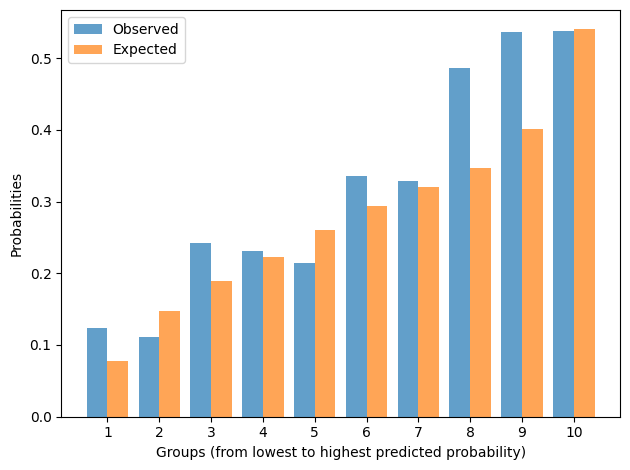

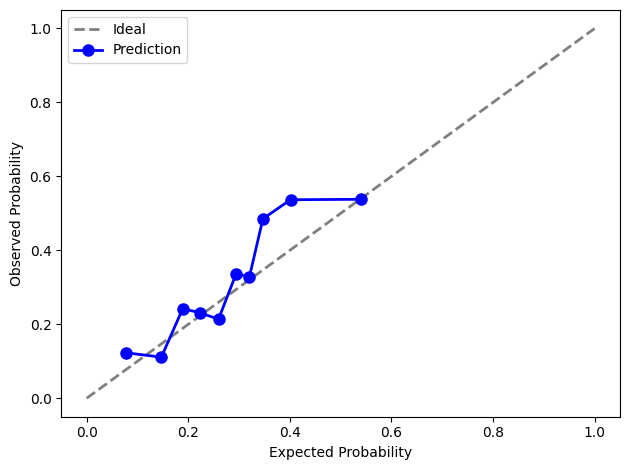

In [14]:
t_time = round(np.percentile(test_event_times, 50))
p_value, one_cal_details = eval.one_calibration(target_time=t_time, method="DN", return_details=True)
if p_value >= 0.05:
    print("The model is one-calibrated at time {}.".format(t_time))
else:
    print("The model is not one-calibrated at time {}.".format(t_time))

plt.show()

## Calculate the distribution calibration (D-Calibration)
Plot the sideways histogram of D-Calibration and P-P plot.

The model is d-calibrated!


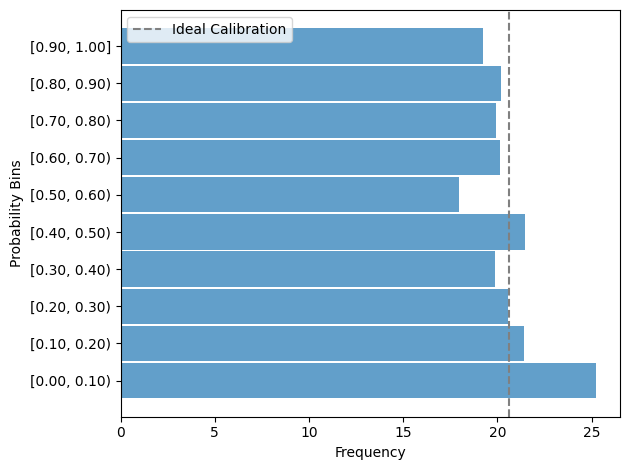

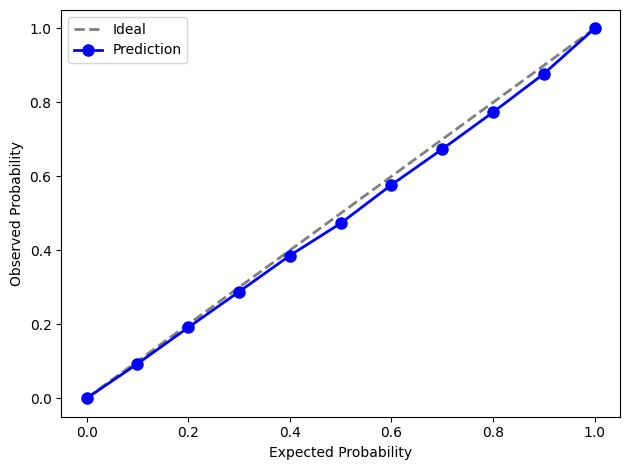

In [15]:
p_value_2, dcal_details = eval.d_calibration(return_details=True)
if p_value_2 >= 0.05:
    print("The model is d-calibrated!")
else:
    print("The model is not d-calibrated!")
plt.show()